In [ ]:

# Installation

import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

pip_install("pycocotools")
pip_install("bitsandbytes>=0.43.0")
pip_install("accelerate>=0.26.0")
pip_install("transformers>=4.40.0")
pip_install("sentencepiece")
pip_install("protobuf")

print("✅ All packages installed.")
print("ℹ️  If this is your first run, restart the kernel now.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.7 MB/s eta 0:00:00


✅ All packages installed.
ℹ️  If this is your first run, restart the kernel now.


In [ ]:
# Imports & Configuration


import os, gc, json, time, random, zipfile, re, warnings
import requests
from io import BytesIO
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional
from collections import defaultdict, Counter

import numpy as np
import torch
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# ── Paths ────────────────────────────────────────────────────
WORK_DIR  = Path("/kaggle/working")
DATA_DIR  = WORK_DIR / "spatialbench_data"
BENCH_DIR = WORK_DIR / "benchmark"
RESULTS_DIR = WORK_DIR / "results"
FIG_DIR   = WORK_DIR / "figures"

for d in [DATA_DIR, BENCH_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ANN_PATH = DATA_DIR / "instances_val2017.json"

# ── Device ───────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {DEVICE}")
if DEVICE == "cuda":
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"   GPU {i}: {props.name}  |  "
              f"{props.total_memory / 1e9:.1f} GB VRAM")

# ── Benchmark Config ─────────────────────────────────────────
@dataclass
class BenchConfig:
    min_objects_per_image: int   = 3
    max_images:            int   = 300
    qa_per_image:          int   = 3
    min_center_separation: float = 0.08
    eval_max_new_tokens:   int   = 80

CFG = BenchConfig()
print(f"✅ Config loaded. Target: ~{CFG.max_images * CFG.qa_per_image} QA pairs.")

✅ Device: cuda
   GPU 0: Tesla T4  |  15.6 GB VRAM
   GPU 1: Tesla T4  |  15.6 GB VRAM
✅ Config loaded. Target: ~900 QA pairs.


In [ ]:
# COCO Annotations Download & Image Loader


def download_coco_annotations(dest: Path) -> None:
    """Download + extract COCO 2017 val annotation JSON."""
    if dest.exists():
        print(f"✅ Annotations found at {dest}")
        return

    ann_zip = DATA_DIR / "annotations_trainval2017.zip"
    if not ann_zip.exists():
        print("⬇️  Downloading COCO annotations zip (~241 MB)…")
        url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
        with requests.get(url, stream=True, timeout=180) as r:
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))
            done  = 0
            with open(ann_zip, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
                    done += len(chunk)
                    if total:
                        print(f"\r   {done/total*100:.1f}%", end="", flush=True)
        print(f"\n✅ Downloaded {ann_zip}")

    print("📦 Extracting instances_val2017.json…")
    with zipfile.ZipFile(ann_zip) as z:
        z.extract("annotations/instances_val2017.json", DATA_DIR)
    (DATA_DIR / "annotations" / "instances_val2017.json").rename(dest)
    print(f"✅ Annotations saved → {dest}")


download_coco_annotations(ANN_PATH)

# ── Load annotation structures ───────────────────────────────
print("📖 Loading COCO annotations…")
with open(ANN_PATH) as f:
    coco_raw = json.load(f)

id2cat   = {c["id"]: c["name"] for c in coco_raw["categories"]}
id2img   = {img["id"]: img     for img in coco_raw["images"]}
img2anns = defaultdict(list)
for ann in coco_raw["annotations"]:
    img2anns[ann["image_id"]].append(ann)

print(f"✅ {len(coco_raw['images']):,} images  |  "
      f"{len(coco_raw['annotations']):,} annotations  |  "
      f"{len(id2cat)} categories")

# ── Image loader (CDN + local cache) ─────────────────────────
_img_cache: dict[int, Image.Image] = {}

def load_coco_image(image_id: int) -> Image.Image:
    """Load COCO val2017 image: tries local Kaggle dataset, then CDN."""
    if image_id in _img_cache:
        return _img_cache[image_id]

    fname = id2img[image_id]["file_name"]
    local = Path(f"/kaggle/input/coco-2017-dataset/val2017/{fname}")
    if local.exists():
        img = Image.open(local).convert("RGB")
    else:
        url = f"http://images.cocodataset.org/val2017/{fname}"
        for attempt in range(3):
            try:
                r = requests.get(url, timeout=20)
                r.raise_for_status()
                img = Image.open(BytesIO(r.content)).convert("RGB")
                break
            except Exception as e:
                if attempt == 2:
                    raise RuntimeError(f"Failed to load {fname}: {e}")
                time.sleep(2)

    _img_cache[image_id] = img
    return img

# Smoke test
_tid = coco_raw["images"][0]["id"]
_timg = load_coco_image(_tid)
print(f"✅ Test image loaded: {_timg.size} (W×H)")

⬇️  Downloading COCO annotations zip (~241 MB)…
   100.0%
✅ Downloaded /kaggle/working/spatialbench_data/annotations_trainval2017.zip
📦 Extracting instances_val2017.json…
✅ Annotations saved → /kaggle/working/spatialbench_data/instances_val2017.json
📖 Loading COCO annotations…
✅ 5,000 images  |  36,781 annotations  |  80 categories
✅ Test image loaded: (640, 427) (W×H)


In [ ]:
# Spatial Relation Engine (Pure Python, No GPU)

@dataclass
class ObjectInfo:
    label:     str
    obj_id:    int
    bbox_xyxy: list          # [x1, y1, x2, y2] in pixels
    cx:        float
    cy:        float
    area:      float
    img_w:     int
    img_h:     int

    @property
    def cx_norm(self) -> float:  return self.cx / self.img_w
    @property
    def cy_norm(self) -> float:  return self.cy / self.img_h
    @property
    def area_norm(self) -> float: return self.area / (self.img_w * self.img_h)


def coco_ann_to_objectinfo(ann: dict, img_meta: dict) -> ObjectInfo:
    x, y, w, h = ann["bbox"]
    return ObjectInfo(
        label     = id2cat[ann["category_id"]],
        obj_id    = ann["id"],
        bbox_xyxy = [x, y, x + w, y + h],
        cx        = x + w / 2,
        cy        = y + h / 2,
        area      = w * h,
        img_w     = img_meta["width"],
        img_h     = img_meta["height"],
    )


class SpatialRelationEngine:
    def __init__(self, sep: float = 0.08):
        self.sep = sep

    def is_left_of(self, a: ObjectInfo, b: ObjectInfo) -> bool:
        return (b.cx - a.cx) / b.img_w > self.sep

    def is_right_of(self, a: ObjectInfo, b: ObjectInfo) -> bool:
        return self.is_left_of(b, a)

    def is_above(self, a: ObjectInfo, b: ObjectInfo) -> bool:
        return (b.cy - a.cy) / b.img_h > self.sep

    def is_below(self, a: ObjectInfo, b: ObjectInfo) -> bool:
        return self.is_above(b, a)

    def euclidean_dist(self, a: ObjectInfo, b: ObjectInfo) -> float:
        dx = (a.cx - b.cx) / a.img_w
        dy = (a.cy - b.cy) / a.img_h
        return (dx**2 + dy**2) ** 0.5

    def nearest(self, ref: ObjectInfo, others: list) -> Optional[ObjectInfo]:
        return min(others, key=lambda o: self.euclidean_dist(ref, o)) if others else None

    def farthest(self, ref: ObjectInfo, others: list) -> Optional[ObjectInfo]:
        return max(others, key=lambda o: self.euclidean_dist(ref, o)) if others else None

    def count_left_of(self, ref: ObjectInfo, others: list) -> int:
        return sum(1 for o in others if self.is_left_of(o, ref))

    def count_right_of(self, ref: ObjectInfo, others: list) -> int:
        return sum(1 for o in others if self.is_right_of(o, ref))

    def build_spatial_context(self, objects: list) -> str:
        """Build natural-language spatial context for SpatialVLM-D."""
        if not objects:
            return ""

        lr  = " → ".join(o.label for o in sorted(objects, key=lambda o: o.cx_norm))
        tb  = " → ".join(o.label for o in sorted(objects, key=lambda o: o.cy_norm))
        sz  = ", ".join(
            f"{o.label} ({o.area_norm*100:.1f}%)"
            for o in sorted(objects, key=lambda o: o.area_norm, reverse=True)[:5]
        )
        rels, engine = [], SpatialRelationEngine()
        for i, a in enumerate(objects):
            for b in objects[i+1:]:
                if engine.is_left_of(a, b):
                    rels.append(f"{a.label} is left of {b.label}")
                elif engine.is_right_of(a, b):
                    rels.append(f"{a.label} is right of {b.label}")
                if engine.is_above(a, b):
                    rels.append(f"{a.label} is above {b.label}")
                elif engine.is_below(a, b):
                    rels.append(f"{a.label} is below {b.label}")
                if len(rels) >= 8:
                    break
            if len(rels) >= 8:
                break

        return (
            f"[Spatial Context]\n"
            f"Left→Right order: {lr}\n"
            f"Top→Bottom order: {tb}\n"
            f"Size (largest first): {sz}\n"
            f"Pairwise relations: {'; '.join(rels) or 'none'}\n"
        )


engine = SpatialRelationEngine(sep=CFG.min_center_separation)

# Sanity checks
def _dummy(label, cx, cy, w=640, h=480):
    return ObjectInfo(label, 0, [cx-20, cy-20, cx+20, cy+20], cx, cy, 1600, w, h)

assert engine.is_left_of(_dummy("a", 100, 240), _dummy("b", 400, 240))
assert engine.is_above(_dummy("a", 300, 100), _dummy("b", 300, 300))
assert engine.nearest(
    _dummy("r", 100, 240),
    [_dummy("x", 200, 240), _dummy("y", 500, 240)]
).label == "x"
print("✅ SpatialRelationEngine — all checks passed.")

✅ SpatialRelationEngine — all checks passed.


In [ ]:
# QA Generator


@dataclass
class QAPair:
    qa_id:       str
    image_id:    int
    category:    str
    question:    str
    gold_answer: str
    gold_type:   str
    distractors: list
    meta:        dict


# Paraphrase templates (3 per direction)
_T = {
    "left":         ["What object is directly to the left of the {ref}?",
                     "Looking at the image, which object appears on the left side of the {ref}?",
                     "Which object is positioned to the left of the {ref}?"],
    "right":        ["What object is directly to the right of the {ref}?",
                     "Looking at the image, which object appears on the right side of the {ref}?",
                     "Which object is positioned to the right of the {ref}?"],
    "above":        ["What object is located above the {ref}?",
                     "Which object can be found above the {ref} in the image?",
                     "What appears above the {ref}?"],
    "below":        ["What object is located below the {ref}?",
                     "Which object can be found below the {ref}?",
                     "What appears below the {ref}?"],
    "nearest":      ["What object is closest to the {ref}?",
                     "Which object is nearest to the {ref} in this scene?",
                     "What is the object most proximate to the {ref}?"],
    "farthest":     ["What object is farthest from the {ref}?",
                     "Which object is the most distant from the {ref}?",
                     "What object is farthest away from the {ref}?"],
    "count_left":   ["How many objects are to the left of the {ref}?",
                     "Count the objects positioned to the left of the {ref}.",
                     "How many objects appear on the left side of the {ref}?"],
    "count_right":  ["How many objects are to the right of the {ref}?",
                     "Count the objects positioned to the right of the {ref}.",
                     "How many objects appear on the right side of the {ref}?"],
}

def _tmpl(key: str, qa_id: str) -> str:
    return _T[key][hash(qa_id) % len(_T[key])]


class QAGenerator:
    def __init__(self, eng: SpatialRelationEngine):
        self.eng = eng

    def generate(self, image_id: int, objects: list,
                 n: int = 3, rng: random.Random = None) -> list:
        rng = rng or random.Random(0)
        pairs = (
            self._directional(image_id, objects, "left",  "left_right")
            + self._directional(image_id, objects, "right", "left_right")
            + self._directional(image_id, objects, "above", "above_below")
            + self._directional(image_id, objects, "below", "above_below")
            + self._proximity(image_id, objects)
            + self._counting(image_id, objects)
        )
        # Deduplicate
        seen, unique = set(), []
        for p in pairs:
            key = (p.category, p.gold_answer, p.question[:25])
            if key not in seen:
                seen.add(key); unique.append(p)
        rng.shuffle(unique)
        return unique[:n]

    def _make_pair(self, qa_id, image_id, cat, direction,
                   ref, answer_obj, others) -> QAPair:
        tmpl = _tmpl(direction, qa_id)
        return QAPair(
            qa_id       = qa_id,
            image_id    = image_id,
            category    = cat,
            question    = tmpl.format(ref=ref.label),
            gold_answer = answer_obj.label,
            gold_type   = "category_name",
            distractors = [o.label for o in others
                           if o.obj_id != answer_obj.obj_id][:3],
            meta        = {"ref_label": ref.label, "direction": direction,
                           "ref_id": ref.obj_id, "answer_id": answer_obj.obj_id},
        )

    def _directional(self, image_id, objects, direction, cat) -> list:
        fn_map = {
            "left":  (self.eng.is_left_of,  lambda a, r: abs(a.cx - r.cx)),
            "right": (self.eng.is_right_of, lambda a, r: abs(a.cx - r.cx)),
            "above": (self.eng.is_above,    lambda a, r: abs(a.cy - r.cy)),
            "below": (self.eng.is_below,    lambda a, r: abs(a.cy - r.cy)),
        }
        check_fn, sort_fn = fn_map[direction]
        pairs = []
        for ref in objects:
            others = [o for o in objects if o.obj_id != ref.obj_id]
            matches = [o for o in others if check_fn(o, ref)]
            if not matches:
                continue
            answer = min(matches, key=lambda o: sort_fn(o, ref))
            qa_id  = f"{direction[:2]}_{image_id:012d}_{ref.obj_id}"
            pairs.append(self._make_pair(qa_id, image_id, cat,
                                         direction, ref, answer, others))
        return pairs

    def _proximity(self, image_id, objects) -> list:
        if len(objects) < 3:
            return []
        pairs = []
        for ref in objects:
            others = [o for o in objects if o.obj_id != ref.obj_id]
            if len(others) < 2:
                continue
            for ptype, fn in [("nearest", self.eng.nearest),
                               ("farthest", self.eng.farthest)]:
                ans = fn(ref, others)
                if ans is None or ans.label == ref.label:
                    continue
                qa_id = f"{ptype[:2]}_{image_id:012d}_{ref.obj_id}"
                pairs.append(self._make_pair(
                    qa_id, image_id, "proximity", ptype, ref, ans, others))
        return pairs

    def _counting(self, image_id, objects) -> list:
        if len(objects) < 3:
            return []
        pairs = []
        for ref in objects:
            others = [o for o in objects if o.obj_id != ref.obj_id]
            for direction, count_fn in [
                ("count_left",  self.eng.count_left_of),
                ("count_right", self.eng.count_right_of),
            ]:
                count = count_fn(ref, others)
                if count == 0 or count == len(others):
                    continue
                qa_id = f"{direction}_{image_id:012d}_{ref.obj_id}"
                tmpl  = _tmpl(direction, qa_id)
                pairs.append(QAPair(
                    qa_id       = qa_id,
                    image_id    = image_id,
                    category    = "counting",
                    question    = tmpl.format(ref=ref.label),
                    gold_answer = str(count),
                    gold_type   = "integer",
                    distractors = [str(c) for c in range(
                        max(0, count-2), count+3) if c != count],
                    meta        = {"ref_label": ref.label, "direction": direction,
                                   "count": count},
                ))
        return pairs


qa_gen = QAGenerator(engine)
print("✅ QAGenerator ready.")

✅ QAGenerator ready.


In [ ]:
# Build & Save Benchmark 

def build_benchmark(image_ids: list, qa_per_image: int = 3) -> list:
    all_pairs, rng = [], random.Random(42)
    for i, img_id in enumerate(image_ids):
        if i % 50 == 0:
            print(f"   {i+1}/{len(image_ids)}…")
        img_meta = id2img[img_id]
        objects  = []
        for ann in img2anns[img_id]:
            if ann.get("iscrowd", 0) == 1:
                continue
            _, _, w, h = ann["bbox"]
            if (w * h) / (img_meta["width"] * img_meta["height"]) < 0.005:
                continue
            objects.append(coco_ann_to_objectinfo(ann, img_meta))
        if len(objects) < CFG.min_objects_per_image:
            continue
        all_pairs.extend(qa_gen.generate(img_id, objects, n=qa_per_image, rng=rng))
    return all_pairs


qualifying   = [iid for iid, anns in img2anns.items()
                if len(anns) >= CFG.min_objects_per_image]
rng_select   = random.Random(42)
rng_select.shuffle(qualifying)
selected_ids = qualifying[:CFG.max_images]
print(f"📋 {len(qualifying):,} qualifying images → selected {len(selected_ids)}")

print("⚙️  Generating QA pairs…")
t0        = time.time()
benchmark = build_benchmark(selected_ids, qa_per_image=CFG.qa_per_image)
print(f"✅ {len(benchmark):,} QA pairs in {time.time()-t0:.1f}s")

# Stats
cat_counts = Counter(p.category for p in benchmark)
print("\n📊 By category:")
for cat, n in sorted(cat_counts.items()):
    print(f"   {cat:<15} {n:>5}  ({n/len(benchmark)*100:.1f}%)")

# Save
BENCH_PATH = BENCH_DIR / "spatialbench_v1.json"
PILOT_PATH = BENCH_DIR / "spatialbench_pilot100.json"
for path, pairs in [(BENCH_PATH, benchmark), (PILOT_PATH, benchmark[:100])]:
    with open(path, "w") as f:
        json.dump({"version": "1.0", "n_pairs": len(pairs),
                   "data": [asdict(p) for p in pairs]}, f, indent=2)
    print(f"✅ Saved {len(pairs):,} pairs → {path}")

📋 3,434 qualifying images → selected 300
⚙️  Generating QA pairs…
   1/300…
   51/300…
   101/300…
   151/300…
   201/300…
   251/300…
✅ 771 QA pairs in 0.1s

📊 By category:
   above_below       196  (25.4%)
   counting          204  (26.5%)
   left_right        167  (21.7%)
   proximity         204  (26.5%)
✅ Saved 771 pairs → /kaggle/working/benchmark/spatialbench_v1.json
✅ Saved 100 pairs → /kaggle/working/benchmark/spatialbench_pilot100.json


In [ ]:
# Load LLaVA-1.6-7B  


from transformers import (
    LlavaNextProcessor,
    LlavaNextForConditionalGeneration,
    BitsAndBytesConfig,
)

MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"
print(f"🔄 Loading {MODEL_ID} in 4-bit quantisation…")

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_compute_dtype    = torch.float16,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type       = "nf4",
)

vlm_processor = LlavaNextProcessor.from_pretrained(MODEL_ID)
vlm_model     = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_cfg,
    device_map          = "auto",
    torch_dtype         = torch.float16,
    low_cpu_mem_usage   = True,
)
vlm_model.eval()

if DEVICE == "cuda":
    used = torch.cuda.memory_allocated() / 1e9
    print(f"✅ Model loaded  |  VRAM in use: {used:.1f} GB")
else:
    print("✅ Model loaded (CPU — slow).")


# ── Answer helpers ───────────────────────────────────────────

def extract_answer(response: str, gold_type: str,
                   distractors: list = None) -> str:
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1]
    response = response.strip()

    if gold_type == "integer":
        nums = re.findall(r"\b(\d+)\b", response)
        return nums[0] if nums else "unknown"

    rlow = response.lower()
    candidates = sorted(id2cat.values(), key=len, reverse=True)
    for cand in candidates:
        if re.search(r"\b" + re.escape(cand.lower()) + r"\b", rlow):
            return cand

    stopwords = {"the","a","an","is","it","in","of","to","and","that","this",
                 "there","object","image","picture","left","right","see",
                 "closest","nearest","answer","appear","appears"}
    for w in re.findall(r"\b[a-z]+\b", rlow):
        if w not in stopwords and len(w) > 2:
            return w
    return "unknown"


def is_correct(pred: str, gold: str, gold_type: str) -> bool:
    pred, gold = pred.strip().lower(), gold.strip().lower()
    if gold_type == "integer":
        return pred == gold
    return pred == gold or pred.rstrip("s") == gold.rstrip("s")


def vlm_answer(image: Image.Image, question: str,
               ctx: str = "", max_new_tokens: int = 80) -> str:
    full_q = (ctx + question) if ctx else question
    conversation = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": full_q},
    ]}]
    prompt = vlm_processor.apply_chat_template(
        conversation, add_generation_prompt=True)
    inputs = vlm_processor(images=image, text=prompt,
                           return_tensors="pt").to(vlm_model.device)
    with torch.no_grad():
        out_ids = vlm_model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False,
            temperature    = None,
            top_p          = None,
            pad_token_id   = vlm_processor.tokenizer.eos_token_id,
        )
    n_in = inputs["input_ids"].shape[1]
    return vlm_processor.batch_decode(
        out_ids[:, n_in:], skip_special_tokens=True)[0].strip()


# Smoke test
print("\n🔬 VLM smoke test…")
_p  = benchmark[0]
_im = load_coco_image(_p.image_id)
_r  = vlm_answer(_im, _p.question)
_pr = extract_answer(_r, _p.gold_type)
print(f"   Q    : {_p.question}")
print(f"   Gold : {_p.gold_answer}")
print(f"   Pred : {_pr}  {'✅' if is_correct(_pr, _p.gold_answer, _p.gold_type) else '❌'}")
print("✅ VLM ready.")

🔄 Loading llava-hf/llava-v1.6-mistral-7b-hf in 4-bit quantisation…


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`.


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Model loaded  |  VRAM in use: 1.8 GB

🔬 VLM smoke test…
   Q    : Which object is the most distant from the person?
   Gold : motorcycle
   Pred : person  ❌
✅ VLM ready.


In [ ]:
# PATCH: improved answer extraction + spatial context


def extract_answer(response: str, gold_type: str,
                   distractors: list = None) -> str:
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1]
    response = response.strip()

    if gold_type == "integer":
        # Prefer numbers after explicit answer markers
        for marker in ["answer is", "answer:", "are ", "total of",
                       "count is", "there are", "i count", "i see"]:
            m = re.search(marker + r"[^\d]*?(\d+)", response.lower())
            if m:
                return m.group(1)
        # Fall back: LAST number in response (often the "final" answer)
        nums = re.findall(r"\b(\d+)\b", response)
        return nums[-1] if nums else "unknown"

    rlow = response.lower()
    # NEW: strip the spatial context echo if VLM regurgitates it
    if "spatial context" in rlow:
        rlow = rlow.split("[spatial context]")[-1]
        # Take only the last 200 chars (the actual answer)
        rlow = rlow[-200:]

    candidates = sorted(id2cat.values(), key=len, reverse=True)
    for cand in candidates:
        if re.search(r"\b" + re.escape(cand.lower()) + r"\b", rlow):
            return cand

    stopwords = {"the","a","an","is","it","in","of","to","and","that","this",
                 "there","object","image","picture","left","right","see",
                 "closest","nearest","answer","appear","appears","order"}
    for w in re.findall(r"\b[a-z]+\b", rlow):
        if w not in stopwords and len(w) > 2:
            return w
    return "unknown"


def get_spatial_ctx(image_id: int, image: Image.Image) -> str:
    """V2: minimal spatial context — relations only, no ordered lists."""
    if USE_GT_OBJECTS:
        img_meta = id2img[image_id]
        objects  = [
            coco_ann_to_objectinfo(ann, img_meta)
            for ann in img2anns[image_id]
            if ann.get("iscrowd", 0) == 0
        ]
    else:
        labels  = list(id2cat.values())
        objects = detect_objects(image, labels)

    if not objects:
        return ""

    eng = engine
    rels = []
    for i, a in enumerate(objects):
        for b in objects[i+1:]:
            if eng.is_left_of(a, b):
                rels.append(f"{a.label} is to the left of {b.label}")
            elif eng.is_right_of(a, b):
                rels.append(f"{a.label} is to the right of {b.label}")
            if eng.is_above(a, b):
                rels.append(f"{a.label} is above {b.label}")
            elif eng.is_below(a, b):
                rels.append(f"{a.label} is below {b.label}")
        if len(rels) >= 12:
            break

    if not rels:
        return ""

    # Append a soft instruction to USE the context
    ctx = (
        "Use the following spatial facts about the image to answer "
        "precisely. Give a single concise answer.\n"
        + "Facts: " + ". ".join(rels[:12]) + ".\n\n"
        + "Question: "
    )
    return ctx



_original_vlm_answer = vlm_answer  # keep reference

def vlm_answer(image, question: str, ctx: str = "",
               max_new_tokens: int = 80) -> str:
    # Counting-specific instruction
    if question.lower().startswith("how many") or "count" in question.lower()[:25]:
        question = question + " Reply with only a single integer."

    full_q = (ctx + question) if ctx else question
    conversation = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": full_q},
    ]}]
    prompt = vlm_processor.apply_chat_template(
        conversation, add_generation_prompt=True)
    inputs = vlm_processor(images=image, text=prompt,
                           return_tensors="pt").to(vlm_model.device)
    with torch.no_grad():
        out_ids = vlm_model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False,
            temperature    = None,
            top_p          = None,
            pad_token_id   = vlm_processor.tokenizer.eos_token_id,
        )
    n_in = inputs["input_ids"].shape[1]
    return vlm_processor.batch_decode(
        out_ids[:, n_in:], skip_special_tokens=True)[0].strip()


import os
for f in RESULTS_DIR.glob("results_*.json"):
    os.remove(f)
    print(f"🗑️  Removed {f.name}")

print("\n✅ Patches applied:")
print("   • Better integer extraction (prefers last number)")
print("   • Spatial context uses relations only (no ordered lists)")
print("   • Counting questions get explicit 'reply with integer' instruction")
print("   • Old results deleted — re-run Cell 9 to evaluate with patches")

🗑️  Removed results_baseline_spatialbench_pilot100.json
🗑️  Removed results_spatial_spatialbench_pilot100.json

✅ Patches applied:
   • Better integer extraction (prefers last number)
   • Spatial context uses relations only (no ordered lists)
   • Counting questions get explicit 'reply with integer' instruction
   • Old results deleted — re-run Cell 9 to evaluate with patches


In [ ]:
# Load Grounding DINO  (~940 MB, for SpatialVLM-D)


from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

GDINO_ID  = "IDEA-Research/grounding-dino-base"
# Use second GPU if available, else same device as VLM
GDINO_DEV = f"cuda:{torch.cuda.device_count()-1}" if DEVICE == "cuda" else "cpu"

print(f"🔄 Loading Grounding DINO on {GDINO_DEV}…")
gdino_processor = AutoProcessor.from_pretrained(GDINO_ID)
gdino_model     = AutoModelForZeroShotObjectDetection.from_pretrained(
    GDINO_ID,
    torch_dtype = torch.float16 if "cuda" in GDINO_DEV else torch.float32,
).to(GDINO_DEV)
gdino_model.eval()
print("✅ Grounding DINO loaded.")


def detect_objects(image: Image.Image, text_labels: list,
                   box_thr: float = 0.35, txt_thr: float = 0.25) -> list:
    """Run Grounding DINO; return list of ObjectInfo."""
    if not text_labels:
        return []
    text_q = " . ".join(text_labels) + " ."
    inputs = gdino_processor(images=image, text=text_q,
                             return_tensors="pt").to(GDINO_DEV)
    with torch.no_grad():
        outputs = gdino_model(**inputs)
    results = gdino_processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        box_threshold=box_thr, text_threshold=txt_thr,
        target_sizes=[image.size[::-1]],
    )[0]
    img_w, img_h = image.size
    objs = []
    for idx, (score, label, box) in enumerate(
        zip(results["scores"], results["labels"], results["boxes"])
    ):
        x1, y1, x2, y2 = box.tolist()
        cx, cy = (x1+x2)/2, (y1+y2)/2
        objs.append(ObjectInfo(
            label=label.strip().lower(), obj_id=idx,
            bbox_xyxy=[x1,y1,x2,y2], cx=cx, cy=cy,
            area=max(0,(x2-x1)*(y2-y1)), img_w=img_w, img_h=img_h,
        ))
    return objs

🔄 Loading Grounding DINO on cuda:1…


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

✅ Grounding DINO loaded.


In [ ]:
# Full Evaluation Loop  (with checkpoint / resume)


# ── Config ───────────────────────────────────────────────────
EVAL_BENCH_PATH = BENCH_PATH    # ← change to BENCH_PATH for full run
CHECKPOINT_EVERY = 25
USE_GT_OBJECTS   = True        # False → use Grounding DINO at test time


def load_benchmark_file(path: Path) -> list:
    with open(path) as f:
        raw = json.load(f)
    return [QAPair(**d) for d in raw["data"]]


def get_spatial_ctx(image_id: int, image: Image.Image) -> str:
    """Build spatial context for SpatialVLM-D from GT or detector."""
    if USE_GT_OBJECTS:
        img_meta = id2img[image_id]
        objects  = [
            coco_ann_to_objectinfo(ann, img_meta)
            for ann in img2anns[image_id]
            if ann.get("iscrowd", 0) == 0
        ]
    else:
        labels  = list(id2cat.values())
        objects = detect_objects(image, labels)
    return engine.build_spatial_context(objects)


def run_evaluation(pairs: list, mode: str, results_path: Path) -> dict:
    results: dict = {}
    if results_path.exists():
        with open(results_path) as f:
            results = json.load(f)
        print(f"   Resuming — {len(results)} done.")

    done_ids  = set(results.keys())
    remaining = [p for p in pairs if p.qa_id not in done_ids]
    total     = len(pairs)
    _img_memo: dict = {}

    print(f"   Mode={mode} | total={total} | remaining={len(remaining)}")

    for i, pair in enumerate(remaining):
        # Load image
        if pair.image_id not in _img_memo:
            try:
                _img_memo[pair.image_id] = load_coco_image(pair.image_id)
            except Exception as e:
                results[pair.qa_id] = {"pred": "unknown", "gold": pair.gold_answer,
                                        "correct": False, "error": str(e),
                                        "category": pair.category,
                                        "gold_type": pair.gold_type, "mode": mode}
                continue

        img = _img_memo[pair.image_id]
        ctx = get_spatial_ctx(pair.image_id, img) if mode == "spatial" else ""

        # Query VLM with retry on OOM
        try:
            response = vlm_answer(img, pair.question, ctx=ctx)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache(); gc.collect(); time.sleep(3)
            try:
                response = vlm_answer(img, pair.question, ctx=ctx)
            except Exception:
                response = "ERROR"

        pred    = extract_answer(response, pair.gold_type, pair.distractors)
        correct = is_correct(pred, pair.gold_answer, pair.gold_type)

        results[pair.qa_id] = {
            "pred": pred, "gold": pair.gold_answer, "correct": correct,
            "response": response[:300], "category": pair.category,
            "gold_type": pair.gold_type, "mode": mode, "image_id": pair.image_id,
        }

        done_total  = len(done_ids) + i + 1
        running_acc = sum(r.get("correct", False) for r in results.values()) / len(results)
        print(f"\r  [{done_total:>4}/{total}] acc={running_acc*100:.1f}%  "
              f"{'✅' if correct else '❌'}  {pair.category:<15} "
              f"pred={pred:<12} gold={pair.gold_answer:<12}",
              end="", flush=True)

        if (i + 1) % CHECKPOINT_EVERY == 0:
            with open(results_path, "w") as f:
                json.dump(results, f)

    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\n✅ Saved → {results_path}")
    return results


eval_pairs    = load_benchmark_file(EVAL_BENCH_PATH)
BASELINE_PATH = RESULTS_DIR / f"results_baseline_{EVAL_BENCH_PATH.stem}.json"
SPATIAL_PATH  = RESULTS_DIR / f"results_spatial_{EVAL_BENCH_PATH.stem}.json"

print("="*60)
print("▶  BASELINE EVALUATION")
print("="*60)
baseline_results = run_evaluation(eval_pairs, "baseline", BASELINE_PATH)

print("\n" + "="*60)
print("▶  SPATIALVLM-D EVALUATION")
print("="*60)
spatial_results = run_evaluation(eval_pairs, "spatial", SPATIAL_PATH)

▶  BASELINE EVALUATION
   Mode=baseline | total=771 | remaining=771
  [ 771/771] acc=27.5%  ❌  left_right      pred=truck        gold=dog          rve
✅ Saved → /kaggle/working/results/results_baseline_spatialbench_v1.json

▶  SPATIALVLM-D EVALUATION
   Mode=spatial | total=771 | remaining=771
  [ 771/771] acc=34.9%  ✅  left_right      pred=dog          gold=dog          rve
✅ Saved → /kaggle/working/results/results_spatial_spatialbench_v1.json


In [ ]:
# Metrics & Results Table


def compute_metrics(results: dict) -> dict:
    by_cat: dict = defaultdict(list)
    total: list  = []
    for r in results.values():
        if "error" in r:
            continue
        c = bool(r["correct"])
        by_cat[r["category"]].append(c)
        total.append(c)
    return {
        "overall":       sum(total)/len(total) if total else 0,
        "n":             len(total),
        "by_category":   {k: sum(v)/len(v) for k,v in by_cat.items()},
        "by_category_n": {k: len(v)         for k,v in by_cat.items()},
    }


base_m    = compute_metrics(baseline_results)
spatial_m = compute_metrics(spatial_results)
all_cats  = sorted(set(list(base_m["by_category"]) + list(spatial_m["by_category"])))

print("\n" + "="*70)
print(f"{'CATEGORY':<20} {'BASELINE':>10} {'SPATIALVLM-D':>14} {'DELTA':>10}")
print("-"*70)
for cat in all_cats:
    b = base_m["by_category"].get(cat, 0) * 100
    s = spatial_m["by_category"].get(cat, 0) * 100
    n = base_m["by_category_n"].get(cat, 0)
    arrow = "▲" if s > b else ("▼" if s < b else "=")
    print(f"  {cat:<18} {b:>9.1f}%  {s:>12.1f}%  {arrow}{abs(s-b):>7.1f}pp  (n={n})")
print("-"*70)
b0, s0 = base_m["overall"]*100, spatial_m["overall"]*100
arrow  = "▲" if s0 > b0 else "▼"
print(f"  {'OVERALL':<18} {b0:>9.1f}%  {s0:>12.1f}%  "
      f"{arrow}{abs(s0-b0):>7.1f}pp  (n={base_m['n']})")
print("="*70)

# Save summary JSON
summary = {
    "benchmark":    str(EVAL_BENCH_PATH.name),
    "model":        MODEL_ID,
    "baseline":     {"overall": base_m["overall"], "by_category": base_m["by_category"]},
    "spatialvlm_d": {"overall": spatial_m["overall"], "by_category": spatial_m["by_category"],
                     "gt_objects": USE_GT_OBJECTS},
    "delta":        spatial_m["overall"] - base_m["overall"],
}
SUMMARY_PATH = RESULTS_DIR / "summary.json"
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\n✅ Summary → {SUMMARY_PATH}")

CATEGORY               BASELINE   SPATIALVLM-D      DELTA
----------------------------------------------------------------------
  above_below             31.6%          40.3%  ▲    8.7pp  (n=196)
  counting                23.5%          22.1%  ▼    1.5pp  (n=204)
  left_right              37.7%          40.7%  ▲    3.0pp  (n=167)
  proximity               19.1%          37.7%  ▲   18.6pp  (n=204)
----------------------------------------------------------------------
  OVERALL                 27.5%          34.9%  ▲    7.4pp  (n=771)

✅ Summary → /kaggle/working/results/summary.json


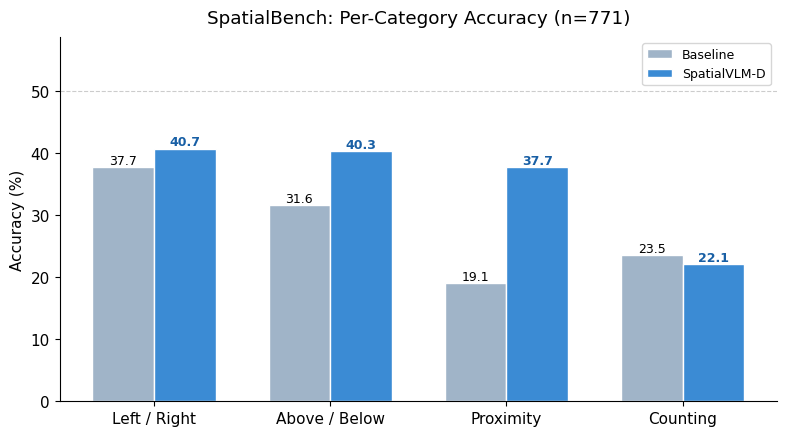

✅ Fig 1 → /kaggle/working/figures/fig1_accuracy_by_category.png


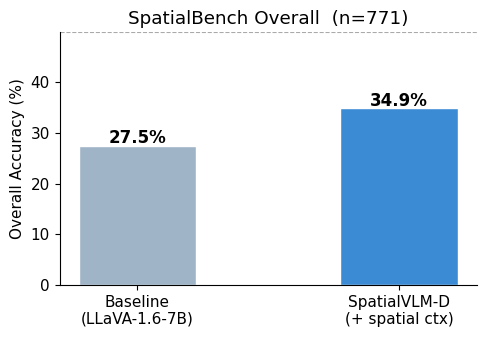

✅ Fig 2 → /kaggle/working/figures/fig2_overall_accuracy.png


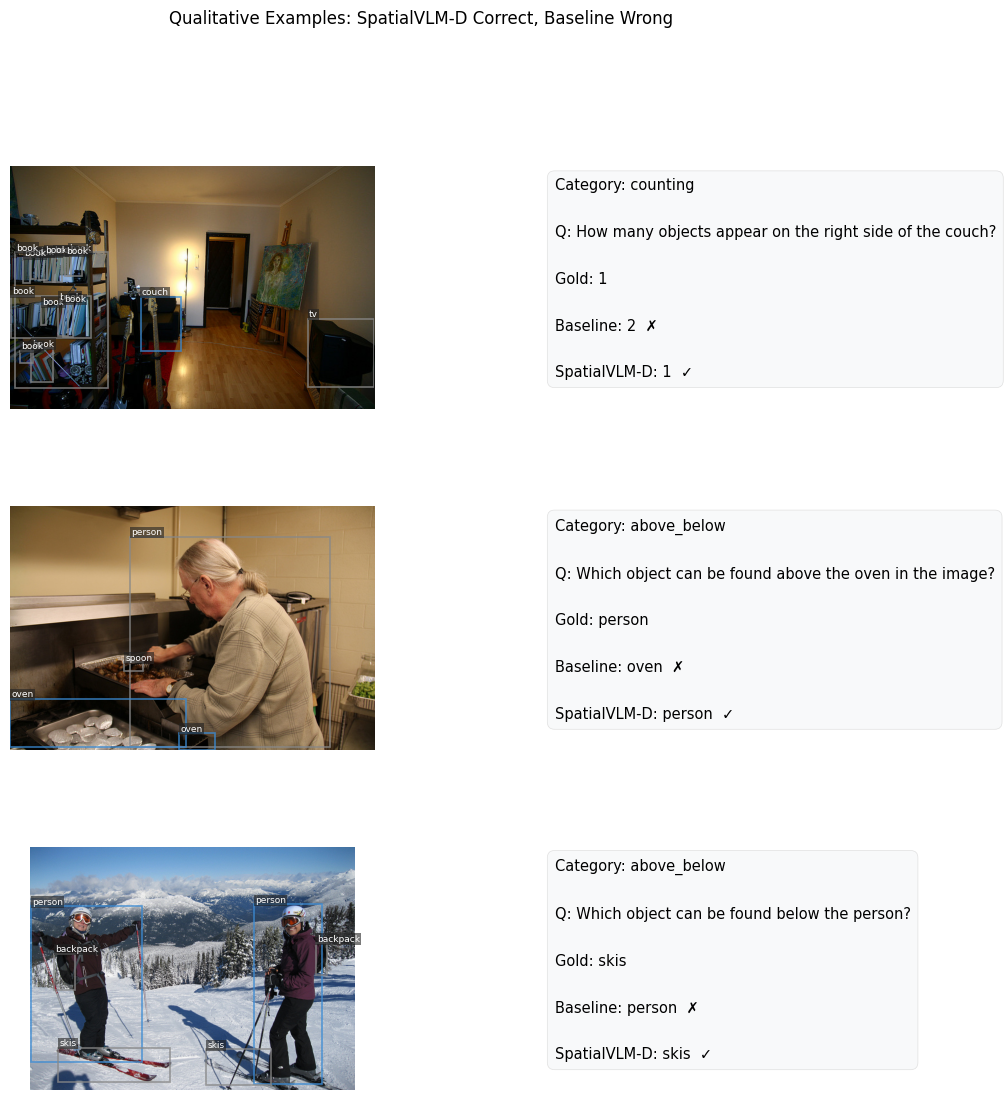

✅ Fig 3 → /kaggle/working/figures/fig3_qualitative.png

📁 All output files:
   .virtual_documents/__notebook_source__.ipynb  (44 KB)
   benchmark/spatialbench_pilot100.json  (46 KB)
   benchmark/spatialbench_v1.json  (352 KB)
   figures/fig1_accuracy_by_category.png  (47 KB)
   figures/fig2_overall_accuracy.png  (36 KB)
   figures/fig3_qualitative.png  (808 KB)
   results/results_baseline_spatialbench_v1.json  (239 KB)
   results/results_spatial_spatialbench_v1.json  (203 KB)
   results/summary.json  (1 KB)
   spatialbench_data/annotations_trainval2017.zip  (252908 KB)
   spatialbench_data/instances_val2017.json  (19988 KB)

🎉 DONE! SpatialBench pipeline complete.
   Baseline accuracy:    27.5%
   SpatialVLM-D accuracy:34.9%
   Delta:                +7.4pp


In [ ]:
# Paper Figures


matplotlib.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                              "axes.spines.top": False, "axes.spines.right": False})
C_BASE, C_SPATIAL = "#A0B4C8", "#3B8BD4"

CAT_LABEL = {
    "left_right":  "Left / Right",
    "above_below": "Above / Below",
    "proximity":   "Proximity",
    "counting":    "Counting",
}

# ── Fig 1: Per-category bar chart ────────────────────────────
cats   = [c for c in CAT_LABEL if c in base_m["by_category"]]
x, w   = np.arange(len(cats)), 0.35
b_vals = [base_m["by_category"].get(c,0)*100 for c in cats]
s_vals = [spatial_m["by_category"].get(c,0)*100 for c in cats]

fig1, ax1 = plt.subplots(figsize=(8, 4.5))
brs_b = ax1.bar(x-w/2, b_vals, w, label="Baseline",        color=C_BASE,    edgecolor="white")
brs_s = ax1.bar(x+w/2, s_vals, w, label="SpatialVLM-D",    color=C_SPATIAL, edgecolor="white")
for bar, val in zip(brs_b, b_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.1f}", ha="center", fontsize=9)
for bar, val in zip(brs_s, s_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.1f}", ha="center",
             fontsize=9, color="#185FA5", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([CAT_LABEL[c] for c in cats])
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, min(100, max(max(b_vals), max(s_vals)) + 18))
ax1.axhline(50, color="#CCC", lw=0.8, ls="--")
ax1.legend(fontsize=9)
ax1.set_title(f"SpatialBench: Per-Category Accuracy (n={base_m['n']})", pad=10)
fig1.tight_layout()
p1 = FIG_DIR / "fig1_accuracy_by_category.png"
fig1.savefig(p1, dpi=150, bbox_inches="tight")
plt.show(); print(f"✅ Fig 1 → {p1}")

# ── Fig 2: Overall accuracy comparison ───────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 3.5))
bars2 = ax2.bar(["Baseline\n(LLaVA-1.6-7B)", "SpatialVLM-D\n(+ spatial ctx)"],
                [b0, s0], color=[C_BASE, C_SPATIAL], edgecolor="white", width=0.45)
for bar, val in zip(bars2, [b0, s0]):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.1f}%",
             ha="center", fontsize=12, fontweight="bold")
ax2.set_ylim(0, min(100, max(b0, s0)+15))
ax2.set_ylabel("Overall Accuracy (%)")
ax2.axhline(50, color="#AAA", lw=0.8, ls="--")
ax2.set_title(f"SpatialBench Overall  (n={base_m['n']})")
fig2.tight_layout()
p2 = FIG_DIR / "fig2_overall_accuracy.png"
fig2.savefig(p2, dpi=150, bbox_inches="tight")
plt.show(); print(f"✅ Fig 2 → {p2}")

# ── Fig 3: Qualitative examples ──────────────────────────────
fail_cases = [
    (qid, baseline_results[qid], spatial_results.get(qid))
    for qid in baseline_results
    if (not baseline_results[qid].get("correct") and
        spatial_results.get(qid, {}).get("correct"))
][:3]

if fail_cases:
    fig3 = plt.figure(figsize=(13, 4 * len(fail_cases)))
    gs   = GridSpec(len(fail_cases), 2, width_ratios=[1.3, 1], hspace=0.4)
    for row, (qid, br, sr) in enumerate(fail_cases):
        pair = next((p for p in eval_pairs if p.qa_id == qid), None)
        if pair is None: continue
        img = load_coco_image(pair.image_id)
        # Image
        ax_i = fig3.add_subplot(gs[row, 0])
        ax_i.imshow(img); ax_i.axis("off")
        for ann in img2anns[pair.image_id]:
            x, y, w, h = ann["bbox"]
            cat = id2cat[ann["category_id"]]
            rect = mpatches.Rectangle((x,y), w, h, lw=1.2,
                edgecolor="#3B8BD4" if cat==pair.meta.get("ref_label") else "#888",
                facecolor="none", alpha=0.8)
            ax_i.add_patch(rect)
            ax_i.text(x+2, y-3, cat, fontsize=6.5, color="white",
                      bbox=dict(facecolor="#222", alpha=0.6, pad=1, lw=0))
        # Text
        ax_t = fig3.add_subplot(gs[row, 1])
        ax_t.axis("off")
        txt  = (f"Category: {pair.category}\n\n"
                f"Q: {pair.question}\n\n"
                f"Gold: {pair.gold_answer}\n\n"
                f"Baseline: {br['pred']}  ✗\n\n"
                f"SpatialVLM-D: {sr['pred'] if sr else 'N/A'}  ✓")
        ax_t.text(0.03, 0.95, txt, transform=ax_t.transAxes, va="top",
                  fontsize=10.5, linespacing=1.7,
                  bbox=dict(facecolor="#F8F9FA", alpha=0.9, pad=10,
                            lw=0.5, edgecolor="#DDD", boxstyle="round,pad=0.5"))
    fig3.suptitle("Qualitative Examples: SpatialVLM-D Correct, Baseline Wrong",
                  fontsize=12, y=1.01)
    p3 = FIG_DIR / "fig3_qualitative.png"
    fig3.savefig(p3, dpi=120, bbox_inches="tight")
    plt.show(); print(f"✅ Fig 3 → {p3}")
else:
    print("ℹ️  No baseline→spatial flip cases found. Expand to full benchmark.")

print(f"\n📁 All output files:")
for f in sorted(WORK_DIR.rglob("*")):
    if f.is_file():
        print(f"   {f.relative_to(WORK_DIR)}  ({f.stat().st_size/1e3:.0f} KB)")

print("\n🎉 DONE! SpatialBench pipeline complete.")
print(f"   Baseline accuracy:    {b0:.1f}%")
print(f"   SpatialVLM-D accuracy:{s0:.1f}%")
print(f"   Delta:                {'+' if s0>b0 else ''}{s0-b0:.1f}pp")